Перевірка даних після очистки: (17293, 9)
--------------------------

Індекси усіх аномалій: (array([  113,   372,   452,   468,   841,   887,   895,  1358,  1381,
        1388,  1390,  1391,  1394,  1396,  1404,  1421,  1434,  1439,
        1897,  2540,  2921,  2927,  3204,  3293,  3372,  3374,  3375,
        3376,  3377,  3384,  3397,  3401,  3436,  3441,  3532,  3541,
        3610,  3634,  3641,  3835,  3847,  4382,  4383,  4385,  4386,
        4388,  4389,  4390,  4392,  4393,  4397,  4402,  4403,  4404,
        4407,  4409,  4411,  4412,  4422,  4431,  4443,  4475,  4483,
        4484,  4491,  4607,  4608,  4821,  4830,  5107,  5218,  5340,
        5355,  5483,  5488,  5521,  5523,  5635,  5643,  5647,  5648,
        5651,  5652,  5820,  5824,  6984,  7273,  7401,  7420,  7422,
        7423,  7424,  7425,  7427,  7430,  7435,  7437,  7438,  7466,
        7486,  7488,  7492,  7612,  7613,  7836,  7868,  7869,  7893,
        7894,  8203,  8500,  8506,  8513,  8516,  8651,  8662,  87

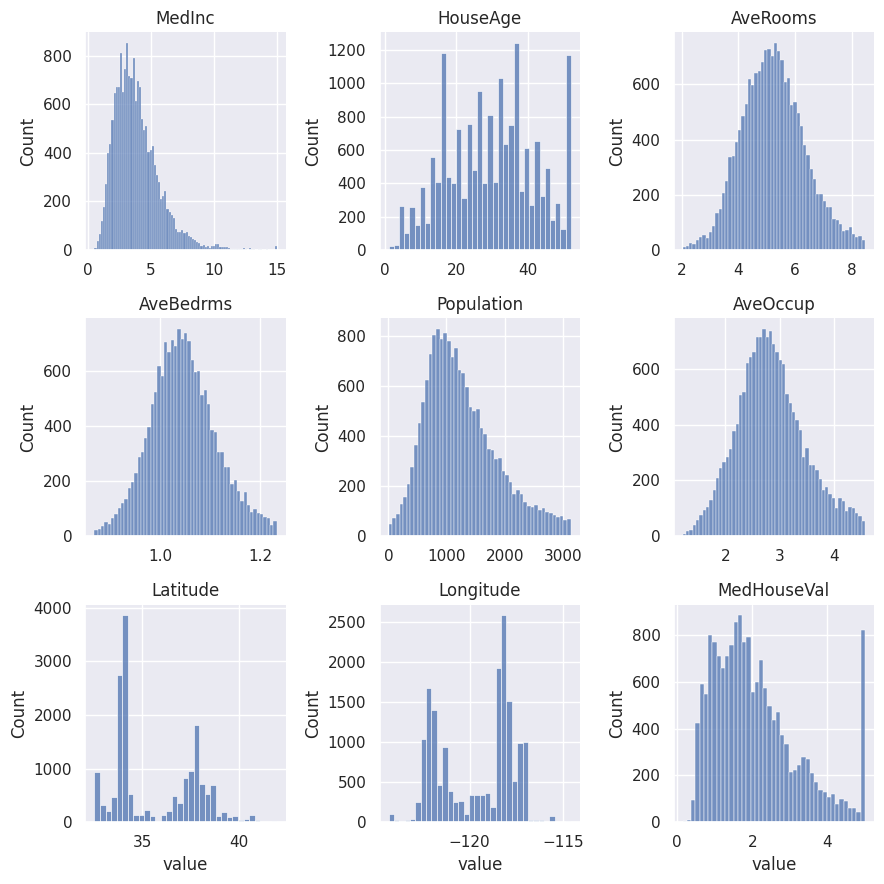

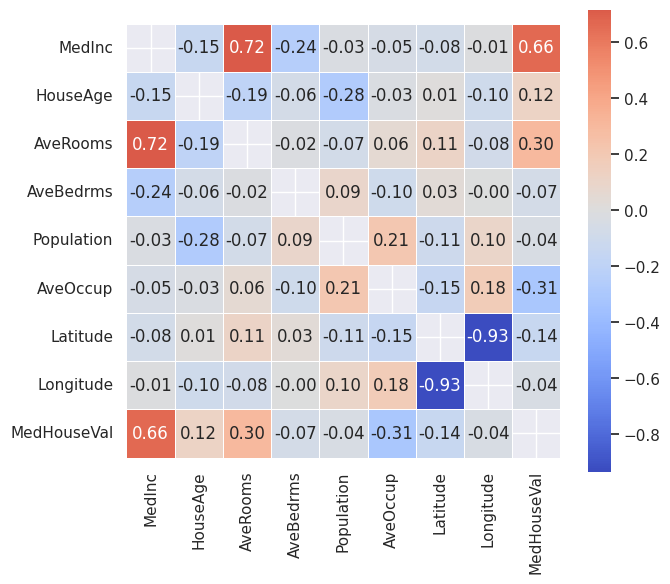

In [26]:
import pandas as pd
from sklearn.datasets import fetch_california_housing
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error

#завантаження набору даних
california_housing = fetch_california_housing(as_frame= True)
data = california_housing['frame']

#очищення викидів
for col in ['AveRooms', 'AveBedrms', 'AveOccup', 'Population']:
    q25 = data[col].quantile(0.25)
    q75 = data[col].quantile(0.75)
    iqr = q75 - q25
    lower_bound = q25 - 1.5 * iqr
    upper_bound = q75 + 1.5 * iqr
    data = data[(data[col] >= lower_bound) & (data[col] <= upper_bound)]

print('Перевірка даних після очистки:', data.shape)
print('--------------------------\n')

#побудова графіків
sns.set_theme()
melted = data.melt()
g = sns.FacetGrid(melted, col='variable', col_wrap=3, sharex=False, sharey=False)
g.map(sns.histplot,'value')
g.set_titles(col_template='{col_name}')
g.tight_layout()

#визначення аномалій
z_scores = np.abs(stats.zscore(data))

#фільтрація
threshold = 3
anomalies = np.where(z_scores > threshold)

print('Індекси усіх аномалій:', anomalies)
print('--------------------------\n')

#видалення аномалій
anomaly_positions = np.unique(anomalies[0])
anomaly_indx = data.index[anomaly_positions]
clean_df = data.drop(index = anomaly_indx)

print('Розмір оригінального датасету:', data.shape)
print('Розмір очищеного датасету:', clean_df.shape)
print('--------------------------\n')

#матриця кореляції
corr_mtx = clean_df.corr()
mask_mtx = np.zeros_like(corr_mtx)
np.fill_diagonal(mask_mtx, 1)

fig, ax = plt.subplots(figsize=(7, 6))

sns.heatmap(corr_mtx, cmap='coolwarm', center=0, annot=True, fmt='.2f', linewidth=0.5, square=True, mask=mask_mtx, ax=ax)

#розділення ознак
x = clean_df.drop(columns = ['MedHouseVal'])
y = clean_df['MedHouseVal']

#розбиття вихідного набору
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

#нормалізація
scaler = StandardScaler()
x_train_scaler = scaler.fit_transform(x_train)
x_test_scaler = scaler.transform(x_test)

print("Розмір x_train_scaler:", x_train_scaler.shape)
print("Розмір y_train:", y_train.shape)
print('--------------------------\n')

#побудова моделі
model = LinearRegression()
model.fit(x_train_scaler, y_train)
y_predict = model.predict(x_test_scaler)
y_min, y_max = y_train.agg(['min','max']).values
y_predict = pd.Series(y_predict, index = x_test.index).clip(y_min, y_max)
y_predict.head()

#оцінка показників моделі
r2 = model.score(x_test_scaler, y_test)
mae = mean_absolute_error(y_test, y_predict)
mape = mean_absolute_percentage_error(y_test, y_predict)

print(f"R2_Score, Коефіцієнт детермінації: {r2:.4f}")
print(f"MAE, Середня абсолютна похибка: {mae:.2f}")
print(f"MAPE, Похибка у відсотках: {mape * 100:.2f}%")
print('--------------------------\n')



ВИСНОВОК

Була незначні проблеми з розділенням даних та навчанням, що вилилось у помірну якість прогнозування моделі. В цілому в непоганий кофіціент детермінації, тобто в більшості випадків модель правильно прогнозує, але все жз якусь частину пропускає. Загалом модель можна використовувати для приблизних прогнозів, але для задач, де потрібна висока точність, вона слабкувата.
